# **1. 선형 회귀 분석**
선형 회귀 분석(Linear Regression)은 주어진 데이터에서 입력 변수(독립 변수)와 출력 변수(종속 변수) 사이의 관계를 직선(또는 다차원에서는 평면)으로 설명하고, 
<br>새로운 입력 값에 대한 출력을 예측하는 통계 및 머신러닝 기법입니다. 
<br>예를 들어, 공부 시간(입력 변수)과 시험 점수(출력 변수) 사이의 관계를 분석해 "공부 시간이 늘어날수록 시험 점수가 증가한다"는 패턴을 찾아냅니다. 
<br>이 과정에서 선형 회귀는 "Y = W X + b"라는 수식(기울기 W와 절편 b)으로 데이터를 표현하며, 
<br>최적의 기울기와 절편을 찾기 위해 비용 함수(Cost Function)를 최소화하는 경사 하강법(Gradient Descent) 등의 알고리즘을 사용합니다. 
<br>최종적으로 선형 회귀 모델은 주어진 입력 값에 대해 가장 적합한 예측 결과를 제공합니다.

# **2. 단항 선형 회귀**
단항 선형 회귀(Simple Linear Regression)는 하나의 독립 변수(입력 변수, X)를 사용하여 하나의 종속 변수(출력 변수, Y)를 예측하는 통계 및 머신러닝 기법입니다. 
<br>입력 변수와 출력 변수 사이의 관계를 직선(Linear Line)으로 나타내며, 데이터의 패턴을 기반으로 가장 잘 맞는 직선을 찾아내어 새로운 입력 값에 대한 출력을 예측합니다.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(2026)

In [3]:
x_train = torch.FloatTensor([[1], [2], [3]])
y_train = torch.FloatTensor([[2], [4], [6]])
print(x_train, x_train.shape)
print(y_train, y_train.shape)

tensor([[1.],
        [2.],
        [3.]]) torch.Size([3, 1])
tensor([[2.],
        [4.],
        [6.]]) torch.Size([3, 1])


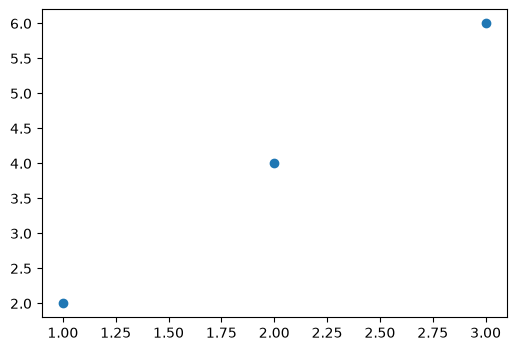

In [4]:
plt.figure(figsize=(6, 4))
plt.scatter(x_train, y_train)

In [5]:
# y = Wx + b # -1 ~ 1 범위 내에서 무작위로 선택
model = nn.Linear(1, 1) # 입력 특성의 수, 출력 특성의 수
print(model)

y_pred = model(x_train)
print(y_pred)
print(list(model.parameters()))

# 출력은 랜덤하게 바뀜
# Linear(in_features=1, out_features=1, bias=True)
# tensor([[-1.1912],
#         [-1.8862],
#         [-2.5813]], grad_fn=<AddmmBackward0>)
# [Parameter containing:
# tensor([[-0.6950]], requires_grad=True), Parameter containing:  W 값
# tensor([-0.4962], requires_grad=True)]                          b 값

Linear(in_features=1, out_features=1, bias=True)
tensor([[-1.1912],
        [-1.8862],
        [-2.5813]], grad_fn=<AddmmBackward0>)
[Parameter containing:
tensor([[-0.6950]], requires_grad=True), Parameter containing:
tensor([-0.4962], requires_grad=True)]


In [6]:
# y = Wx + b # -1 ~ 1 범위 내에서 무작위로 선택
model = nn.Linear(1, 1) # 입력 특성의 수, 출력 특성의 수
print(model)

y_pred = model(x_train)
print(y_pred)
print(list(model.parameters()))



# print()
# print()
# # y = Wx + b # -1 ~ 1 범위 내에서 무작위로 선택
# model = nn.Linear(1, 1) # 입력 특성의 수, 출력 특성의 수
# print(model)

# y_pred = model(x_train)
# print(y_pred)
# print(list(model.parameters()))


Linear(in_features=1, out_features=1, bias=True)
tensor([[-0.4095],
        [ 0.0525],
        [ 0.5146]], grad_fn=<AddmmBackward0>)
[Parameter containing:
tensor([[0.4620]], requires_grad=True), Parameter containing:
tensor([-0.8715], requires_grad=True)]


In [7]:
# W: -0.6950
# b: -0.4962
# y = Wx + b
print(-0.6950 * 1 + (-0.4962))
print(-0.6950 * 2 + (-0.4962))
print(-0.6950 * 3 + (-0.4962))
# print()
# print()
# print(0.3964 * 1 + (-0.9071))
# print(0.3964 * 2 + (-0.9071))
# print(0.3964 * 3 + (-0.9071))
# print()
# print()
# print(0.6259 * 1 + (-0.6091))
# print(0.6259 * 2 + (-0.6091))
# print(0.6259 * 3 + (-0.6091))

-1.1911999999999998
-1.8861999999999999
-2.5812


### 손실 함수

손실 함수(Loss Function)는 머신러닝과 딥러닝 모델이 예측한 값과 실제 값 사이의 차이를 수치적으로 나타내는 함수입니다. 
<br>모델이 학습을 통해 최적의 결과를 도출하려면 이 차이를 최소화해야 합니다. 
<br>손실 함수는 예측값과 실제값의 오차를 계산하여 하나의 숫자(스칼라 값)로 반환하며, 이 값은 비용(Cost) 또는 오차(Error)라고도 불립니다. 
<br>예를 들어, 회귀 문제에서는 주로 평균 제곱 오차(MSE, Mean Squared Error)를 사용하여 예측값과 실제값 간의 평균적인 차이를 측정하고, 
<br>분류 문제에서는 교차 엔트로피 손실(Cross-Entropy Loss)을 사용해 예측 확률 분포와 실제 레이블 분포 간의 차이를 계산합니다. 
<br>손실 함수가 반환한 값은 역전파(Backpropagation)를 통해 모델의 가중치와 편향을 조정하는 데 사용됩니다. 
<br>즉, 손실 함수는 모델이 학습 과정에서 목표로 삼아야 할 방향을 알려주는 나침반 역할을 합니다.

![손실함수](./images/손실함수.png)

![파이토치_기본_손실함수](./images/파이토치_기본_손실함수.png)

In [8]:
((y_pred - y_train)**2).mean()

tensor(17.1593, grad_fn=<MeanBackward0>)

In [9]:
# mseloss = nn.MSELoss()
# loss = mseloss(y_pred, y_train)
loss = nn.MSELoss()(y_pred, y_train)
loss

tensor(17.1593, grad_fn=<MseLossBackward0>)

### 최적화

최적화(Optimization)는 주어진 목표를 달성하기 위해 최상의 해결책(Optimal Solution)을 찾아가는 과정입니다. 
<br>머신러닝과 딥러닝에서는 주로 모델이 예측한 값과 실제 값 사이의 오차(손실 함수 값)를 최소화하는 것을 목표로 합니다. 
<br>이 과정에서 모델의 학습 가능한 파라미터(가중치와 편향)를 조정하여 손실 함수의 값을 점점 더 작게 만들어갑니다. 
<br>최적화는 주로 경사 하강법(Gradient Descent)과 같은 알고리즘을 사용해 수행되며, 손실 함수의 기울기(Gradient)를 따라가며 최저점(또는 최적점)을 찾습니다. 
<br>이 과정은 마치 산에서 가장 낮은 지점을 찾아 내려가는 것과 비슷합니다. 
<br>최적화는 단순히 손실을 줄이는 것뿐만 아니라, 학습 속도, 안정성, 과적합 방지와 같은 다양한 요소를 고려해야 하는 복합적인 과정입니다. 
<br>즉, 최적화는 모델이 데이터로부터 가장 정확하고 효율적인 예측을 할 수 있도록 파라미터를 조정하는 핵심 과정입니다.

### 경사하강법

경사하강법(Gradient Descent)은 머신러닝과 딥러닝 모델이 최적의 가중치(Weights)와 편향(Biases)를 찾기 위해 손실 함수(Loss Function)를 최소화하는 방법입니다. 
<br>이 알고리즘은 마치 산 꼭대기에서 출발해 가장 낮은 지점(최솟값)을 찾아 내려가는 과정과 비슷합니다. 
<br>먼저, 모델은 손실 함수의 기울기(Gradient)를 계산합니다. 이 기울기는 현재 지점에서 손실이 가장 빠르게 감소하는 방향을 나타냅니다. 
<br>이후, 모델은 기울기의 반대 방향으로 가중치와 편향 값을 조금씩 업데이트합니다. 이때 학습률(Learning Rate)은 한 번에 이동하는 "걸음의 크기"를 결정합니다. 
<br>학습률이 너무 크면 최적의 지점을 지나칠 수 있고, 너무 작으면 학습 속도가 매우 느려질 수 있습니다. 
<br>이 과정을 반복하면서 손실 함수 값이 점점 작아지고, 결국 최적의 가중치와 편향을 찾아내게 됩니다. 
<br>즉, 경사하강법은 모델이 더 나은 예측을 할 수 있도록 가중치를 조정해주는 핵심 최적화 알고리즘입니다.

### 학습률

학습률(Learning Rate)은 머신러닝과 딥러닝 모델이 학습할 때 가중치(Weights)와 편향(Biases)를 얼마나 크게 조정할지를 결정하는 하이퍼파라미터입니다. 
<br>경사하강법(Gradient Descent)과 같은 최적화 알고리즘에서 손실 함수(Loss Function)의 기울기(Gradient)를 따라 최적의 가중치를 찾아갈 때, 
<br>학습률은 한 번의 업데이트에서 이동하는 "걸음의 크기"를 의미합니다. 학습률이 너무 크면 최적의 가중치를 지나쳐 버리거나 학습이 불안정해질 수 있고, 
<br>너무 작으면 학습 속도가 매우 느려져 최적값에 도달하기 어려울 수 있습니다. 
<br>따라서 적절한 학습률을 선택하는 것은 모델의 학습 속도와 최적화 성능을 결정하는 중요한 요소입니다. 
<br>일반적으로 고정된 학습률을 사용하기도 하지만, 상황에 따라 학습률을 점진적으로 줄이거나 
<br>동적으로 조정하는 방법(예: Adam, Step Decay, Cyclical Learning Rate 등)이 사용되기도 합니다.

![경사하강법](./images/경사하강법.png)

### 확률적 경사하강법

SGD(Stochastic Gradient Descent, 확률적 경사하강법)는 모델의 가중치(Weights)와 편향(Biases)를 최적화하기 위해 
<br>손실 함수(Loss Function)의 기울기(Gradient)를 따라 반복적으로 업데이트하는 가장 기본적인 옵티마이저입니다. 
<br>일반적인 경사하강법은 전체 데이터셋을 한 번에 사용해 기울기를 계산하지만, 
<br>SGD는 무작위로 선택된 하나의 데이터 포인트(순수 SGD) 또는 작은 그룹(미니배치 SGD)을 사용해 기울기를 계산하고 가중치를 조정합니다. 
<br>이로 인해 학습 속도가 빨라지고 메모리 사용량이 줄어들지만, 진동이 발생할 수 있어 학습이 불안정할 수도 있습니다. PyTorch에서 SGD는 optim.SGD로 구현되며, 
<br>학습률(lr)과 모멘텀(momentum) 등의 매개변수를 통해 조정할 수 있습니다. 
<br>주로 작은 데이터셋이나 빠른 반복 학습이 필요한 경우 사용되며, 학습률이 적절하게 설정되면 강력하고 효율적인 최적화 결과를 제공합니다.

In [10]:
# 위에 나오는 SGD는 파이토치에서 나온 알고리즘

![경사하강법의_종류.png](./images/경사하강법의_종류.png)

In [11]:
model.parameters()

<generator object Module.parameters at 0x000001A6BC097140>

In [12]:
optimizer = optim.SGD(model.parameters(), lr=0.01) # 핵심

In [13]:
# 핵심
optimizer.zero_grad() # 옵티마이저 초기화 진행
loss.backward() # 지금 순전파는 진행된 상태라 역전파 진행
optimizer.step()

In [14]:
# W: -0.6950 재실행 해서 값 달라짐 참고
# b: -0.4962
# y = Wx + b
print(list(model.parameters()))

[Parameter containing:
tensor([[0.6404]], requires_grad=True), Parameter containing:
tensor([-0.7925], requires_grad=True)]


In [15]:
# 핵심
# 반복 학습을 통해 오차가 있는 W, b를 수정하면서 오차를 계속 줄여나감
# epochs: 반복 학습 횟수(에포크)
epochs = 10000

for epoch in range(1, epochs + 1):
    y_pred = model(x_train)
    loss = nn.MSELoss()(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f'Epoch: {epoch}/{epochs} Loss: {loss:.6f}')
    # print(f'Epoch: {epoch}/{epochs} Loss: {loss:.6f}')

print(list(model.parameters()))

Epoch: 100/10000 Loss: 0.002364
Epoch: 200/10000 Loss: 0.001461
Epoch: 300/10000 Loss: 0.000903
Epoch: 400/10000 Loss: 0.000558
Epoch: 500/10000 Loss: 0.000345
Epoch: 600/10000 Loss: 0.000213
Epoch: 700/10000 Loss: 0.000132
Epoch: 800/10000 Loss: 0.000081
Epoch: 900/10000 Loss: 0.000050
Epoch: 1000/10000 Loss: 0.000031
Epoch: 1100/10000 Loss: 0.000019
Epoch: 1200/10000 Loss: 0.000012
Epoch: 1300/10000 Loss: 0.000007
Epoch: 1400/10000 Loss: 0.000005
Epoch: 1500/10000 Loss: 0.000003
Epoch: 1600/10000 Loss: 0.000002
Epoch: 1700/10000 Loss: 0.000001
Epoch: 1800/10000 Loss: 0.000001
Epoch: 1900/10000 Loss: 0.000000
Epoch: 2000/10000 Loss: 0.000000
Epoch: 2100/10000 Loss: 0.000000
Epoch: 2200/10000 Loss: 0.000000
Epoch: 2300/10000 Loss: 0.000000
Epoch: 2400/10000 Loss: 0.000000
Epoch: 2500/10000 Loss: 0.000000
Epoch: 2600/10000 Loss: 0.000000
Epoch: 2700/10000 Loss: 0.000000
Epoch: 2800/10000 Loss: 0.000000
Epoch: 2900/10000 Loss: 0.000000
Epoch: 3000/10000 Loss: 0.000000
Epoch: 3100/10000 L

In [16]:
print(list(model.parameters()))

[Parameter containing:
tensor([[2.0000]], requires_grad=True), Parameter containing:
tensor([-1.7225e-05], requires_grad=True)]


In [17]:
# 2.0000x -2.2413e-05
x_test = torch.FloatTensor([[5]])
y_pred = model(x_test)
print(y_pred)

tensor([[10.0000]], grad_fn=<AddmmBackward0>)


# **3. 다중 선형 회귀**
다중 선형 회귀(Multiple Linear Regression)는 여러 개의 독립 변수(입력 변수)를 사용해 하나의 종속 변수(출력 변수)를 예측하는 통계 및 머신러닝 기법입니다. 
<br>단순 선형 회귀가 하나의 독립 변수와 하나의 종속 변수 간의 선형 관계를 설명하는 반면, 다중 선형 회귀는 두 개 이상의 입력 변수가 출력 변수에 어떻게 영향을 미치는지를 분석합니다. 
<br>이 관계는 수식으로 표현되며, 예를 들어 Y=W1X1+W2X2+...+WnXn+b와 같이 나타납니다. 
<br>여기서 Y는 예측 값, X1,X2,...Xn ​은 입력 변수, W1,W2,...Wn ​은 각 변수의 가중치, b는 절편입니다. 
<br>다중 선형 회귀는 입력 변수들이 독립적이고, 종속 변수와 선형 관계를 가진다는 가정 하에 작동하며, 
<br>주로 경제학, 의료, 마케팅 등 다양한 분야에서 복합적인 요인의 영향을 분석하고 예측하는 데 사용됩니다.

In [18]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cpu


In [19]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

X_train = torch.FloatTensor([
        [50, 55, 60],   # 학생 1
        [60, 65, 70],   # 학생 2
        [70, 72, 75],   # 학생 3
        [75, 80, 78],   # 학생 4
        [80, 82, 85],   # 학생 5
        [88, 90, 92],   # 학생 6
        [95, 96, 98]   # 학생 7                         
   	]).to(device)

y_train = torch.FloatTensor([
    [58],
    [67],
    [73],
    [78],
    [83],
    [90],
    [97],
]).to(device)

print(X_train, X_train.shape)
print(y_train, y_train.shape)

device: cpu
tensor([[50., 55., 60.],
        [60., 65., 70.],
        [70., 72., 75.],
        [75., 80., 78.],
        [80., 82., 85.],
        [88., 90., 92.],
        [95., 96., 98.]]) torch.Size([7, 3])
tensor([[58.],
        [67.],
        [73.],
        [78.],
        [83.],
        [90.],
        [97.]]) torch.Size([7, 1])


In [20]:
# y = W1 x 1 + W2 x 2 + W3 x 3 + b
model = nn.Linear(3, 1).to(DEVICE)
print(model)

Linear(in_features=3, out_features=1, bias=True)


In [21]:
loss_fn = nn.MSELoss()

# Adam
Adam(Adaptive Moment Estimation)은 경사하강법(Gradient Descent)을 개선한 최적화 알고리즘으로, 머신러닝과 딥러닝 모델 학습에서 널리 사용됩니다. 
<br>Adam은 SGD(Stochastic Gradient Descent)의 단점을 보완하기 위해 개발되었으며, 
각 가중치(Weight)와 편향(Bias)마다 다른 학습률(Learning Rate)을 적용해 더욱 효율적이고 안정적으로 최적화를 수행합니다. 

Adam은 모든 가중치에 똑같은 크기의 학습률을 그대로 적용하지 않습니다. 각 가중치의 기울기 상태를 확인하면서 실제 업데이트 크기를 자동으로 조절합니다. 
<br>따라서 코드에 lr=0.01을 지정했더라도 모든 가중치가 항상 정확히 0.01만큼 수정되는 것은 아닙니다.

1. Adam은 이전 기울기의 방향을 기억합니다.
- Adam은 현재 계산된 기울기만 사용하는 것이 아니라 이전 학습에서 계산된 기울기의 흐름도 함께 사용합니다.
<br>이를 1차 모멘트라고 합니다. 최근까지 가중치가 어느 방향으로 계속 움직이고 있었는지를 기억하는 것입니다. 
<br>기울기가 여러 번 같은 방향으로 나타나면 Adam은 그 방향이 손실을 줄이는 데 도움이 되는 방향이라고 판단합니다.

 

2. Adam은 기울기의 크기도 기억합니다.
- Adam은 기울기의 방향뿐만 아니라 기울기가 얼마나 컸는지도 기억합니다. 이를 2차 모멘트라고 합니다. 
<br>기울기가 지나치게 큰 가중치는 업데이트 크기를 줄이고, 기울기가 상대적으로 작은 가중치는 적절히 업데이트되도록 조절합니다.

 

3. Adam이라고 항상 가장 좋은 것은 아닙니다
- Adam은 편리하고 빠르게 학습되는 경우가 많지만 항상 최고의 선택은 아닙니다. 
<br>입력 데이터를 정규화하거나 표준화하면 학습이 더 안정적으로 진행됩니다.  
<br>단순한 문제의 경우 SGD로도 충분히 학습할 수 있습니다. 
<br>Adam을 사용한 것은 입력값 크기에 따른 학습 불안정을 어느 정도 줄이는 데 도움이 됩니다. 
<br>그러나 Adam이 데이터 전처리를 완전히 대신해 주는 것은 아닙니다.

In [22]:
# optimizer = optim.SGD(model.parameters(), lr=0.00001)
optimizer = optim.Adam(model.parameters(), lr= 0.01)    # 강사님은 lr = 0.01

In [23]:
loss_fn = nn.MSELoss()

epochs = 3000

for epoch in range(epochs + 1):

    y_pred = model(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f'Epoch: {epoch}/{epochs}, Loss: {loss.item():.6f}')



Epoch: 0/3000, Loss: 9584.809570
Epoch: 100/3000, Loss: 0.909817
Epoch: 200/3000, Loss: 0.356100
Epoch: 300/3000, Loss: 0.354150
Epoch: 400/3000, Loss: 0.351803
Epoch: 500/3000, Loss: 0.349105
Epoch: 600/3000, Loss: 0.346082
Epoch: 700/3000, Loss: 0.342761
Epoch: 800/3000, Loss: 0.339158
Epoch: 900/3000, Loss: 0.335289
Epoch: 1000/3000, Loss: 0.331170
Epoch: 1100/3000, Loss: 0.326818
Epoch: 1200/3000, Loss: 0.322245
Epoch: 1300/3000, Loss: 0.317465
Epoch: 1400/3000, Loss: 0.312496
Epoch: 1500/3000, Loss: 0.307349
Epoch: 1600/3000, Loss: 0.302040
Epoch: 1700/3000, Loss: 0.296590
Epoch: 1800/3000, Loss: 0.291010
Epoch: 1900/3000, Loss: 0.285325
Epoch: 2000/3000, Loss: 0.279546
Epoch: 2100/3000, Loss: 0.273698
Epoch: 2200/3000, Loss: 0.267799
Epoch: 2300/3000, Loss: 0.261870
Epoch: 2400/3000, Loss: 0.255931
Epoch: 2500/3000, Loss: 0.250006
Epoch: 2600/3000, Loss: 0.244116
Epoch: 2700/3000, Loss: 0.238282
Epoch: 2800/3000, Loss: 0.232529
Epoch: 2900/3000, Loss: 0.226873
Epoch: 3000/3000, L

In [24]:
print("\n모델 파라미터:")
for param in model.parameters():
    print(param)

# 모델 파라미터:
# Parameter containing:
#            W1      W2     W3
# tensor([[0.2314, 0.1226, 0.6198]], requires_grad=True)
# Parameter containing:
#          bias
# tensor([2.0048], requires_grad=True)


모델 파라미터:
Parameter containing:
tensor([[-0.0960,  0.4103,  0.6765]], requires_grad=True)
Parameter containing:
tensor([-0.4336], requires_grad=True)


In [25]:
x_test = torch.FloatTensor([[90, 91, 92]]).to(device)
y_pred = model(x_test)
print(f"\n새로운 입력 데이터 {x_test.tolist()}의 예측 결과: {y_pred.item():.4f}")


새로운 입력 데이터 [[90.0, 91.0, 92.0]]의 예측 결과: 90.5009
